<a href="https://colab.research.google.com/github/mjawadiqbal5-jpg/Diamond-Price-Predictions/blob/main/Predicting_Live_GBP_to_BDT_Rates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from datetime import datetime

In [99]:
# 1. Download Historical Data (GBP to BDT)
today = datetime.now().strftime('%Y-%m-%d')
tickers = ['GBPBDT=X', 'USDBDT=X']
raw_data = yf.download(tickers, start='2023-01-01', end=today, interval='1d')['Close']

# 2: Data Cleaning
data = raw_data.ffill().dropna()
data.columns = ['GBP_BDT', 'USD_BDT'] # For clarity

# We are now scaling TWO features instead of one
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values)

print()

# display rows and shape
print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")

# Display dataset
print()
print("\nData Prepared for 2023-2026 Analysis")
data

/tmp/ipykernel_1297/1344072127.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start='2023-01-01', end=today, interval='1d')['Close']
[*********************100%***********************]  2 of 2 completed


Rows: 868
Columns: 2


Data Prepared for 2023-2026 Analysis


,GBP_BDT,USD_BDT
Date,,
2023-01-02,122.147301,101.473038
2023-01-03,126.262024,104.777618
2023-01-04,121.310402,101.698990
2023-01-05,122.923592,101.981415
2023-01-06,122.581963,102.014275
...,...,...
2026-04-30,163.722916,121.198402
2026-05-01,163.722916,121.198402
2026-05-04,163.918152,121.188316


Total sequences: 808
Features used: 2 (GBP and USD)

Training set summary (Target: Close):
count    646.000000
mean       0.532290
std        0.233974
min        0.115471
25%        0.329035
50%        0.566289
75%        0.728742
max        1.000000
dtype: float64

Testing set summary (Target: Close):
count    162.000000
mean       0.888589
std        0.043493
min        0.780706
25%        0.865014
50%        0.890374
75%        0.916051
max        0.990422
dtype: float64


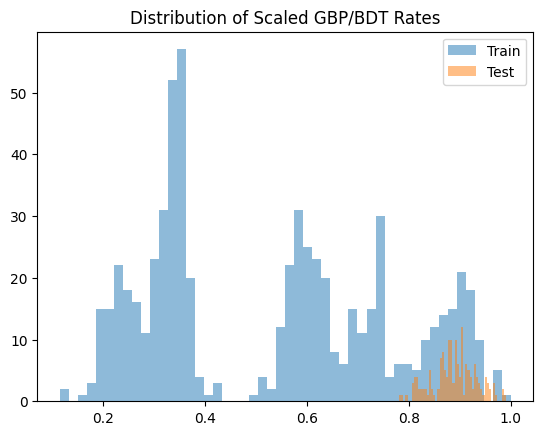

In [100]:
# 3. Training/Testing Split
# Create sequences (60 days of history to predict 1 day)
prediction_days = 60
X, y = [], []

for x in range(prediction_days, len(scaled_data)):
    # X now contains 60 days of BOTH GBP and USD
    X.append(scaled_data[x-prediction_days:x, :])
    # y remains only the GBP price (what we want to predict)
    y.append(scaled_data[x, 0])

X, y = np.array(X), np.array(y)

# Chronological Split (80% Train, 20% Test)
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# No manual reshape needed
print(f"Total sequences: {len(X)}")
print(f"Features used: {X.shape[2]} (GBP and USD)")

# Check distribution using descriptive statistics (Mean, Min, Max, etc.)
print("\nTraining set summary (Target: Close):")
print(pd.Series(y_train.flatten()).describe())

print("\nTesting set summary (Target: Close):")
print(pd.Series(y_test.flatten()).describe())

# OPTIONAL: Visual check of the distribution (Step 5)
import matplotlib.pyplot as plt
plt.hist(y_train, bins=50, alpha=0.5, label='Train')
plt.hist(y_test, bins=50, alpha=0.5, label='Test')
plt.title("Distribution of Scaled GBP/BDT Rates")
plt.legend()
plt.show()

In [101]:
# 4. Build Trained Model
model = Sequential([
    # input_shape updated to (60, 2)
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2), # prevents overfitting
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1) # Final predicted price
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
# We use 'validation_data' to monitor performance during training
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.0219 - val_loss: 0.0017
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0089 - val_loss: 0.0019
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0065 - val_loss: 0.0100
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.0068 - val_loss: 9.2869e-04
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0053 - val_loss: 8.2659e-04
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0051 - val_loss: 0.0012
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0045 - val_loss: 0.0028
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0046 - val_loss: 8.1606e-04
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0047 - val_loss: 8.5597e-04
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0042 - val_loss: 0.0010
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0039 - val_loss: 0.0017
Epoch 12/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/

In [102]:
# 5. Make Predictions

# 1. Generate predictions for the Test set (Step 7)
test_predictions_scaled = model.predict(X_test)

# 2. Inverse transform both to get actual Taka values
dummy_test = np.zeros((len(test_predictions_scaled), 2))
dummy_test[:, 0] = test_predictions_scaled.flatten()
test_predictions = scaler.inverse_transform(dummy_test)[:, 0]

dummy_actual = np.zeros((len(y_test), 2))
dummy_actual[:, 0] = y_test
actual_test_prices = scaler.inverse_transform(dummy_actual)[:, 0]

# 3. Calculate Accuracy Metric (RMSE)
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(actual_test_prices, test_predictions))
print(f"\nModel Evaluation (Test Set) RMSE: {rmse:.2f} BDT")

print(f"\nModel Evaluation (Test Set):")
print(f"Root Mean Squared Error: {rmse:.2f} BDT")

# --- NEW: 30-DAY RECURSIVE FORECAST ---
# 4. Start with the absolute latest 60 days
current_batch = scaled_data[-prediction_days:].reshape(1, prediction_days, 2)
future_predictions_scaled = []

for i in range(30):
    # 5. We take the predicted GBP and the last known USD value to form the next input row
    next_pred = model.predict(current_batch, verbose=0)
    future_predictions_scaled.append(next_pred[0])

    # 6. Update batch: remove first day, append the prediction
    new_row = np.array([[next_pred[0][0], current_batch[0, -1, 1]]])
    new_row_reshaped = new_row.reshape(1, 1, 2)
    current_batch = np.append(current_batch[:, 1:, :], new_row_reshaped, axis=1)

# 7. Inverse transform only the GBP predictions
dummy_future = np.zeros((30, 2))
dummy_future[:, 0] = np.array(future_predictions_scaled).flatten()
future_forecast = scaler.inverse_transform(dummy_future)[:, 0]

last_date = data.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)
forecast_df = pd.DataFrame(future_forecast, index=forecast_dates, columns=['Predicted'])

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step

Model Evaluation (Test Set) RMSE: 1.53 BDT

Model Evaluation (Test Set):
Root Mean Squared Error: 1.53 BDT


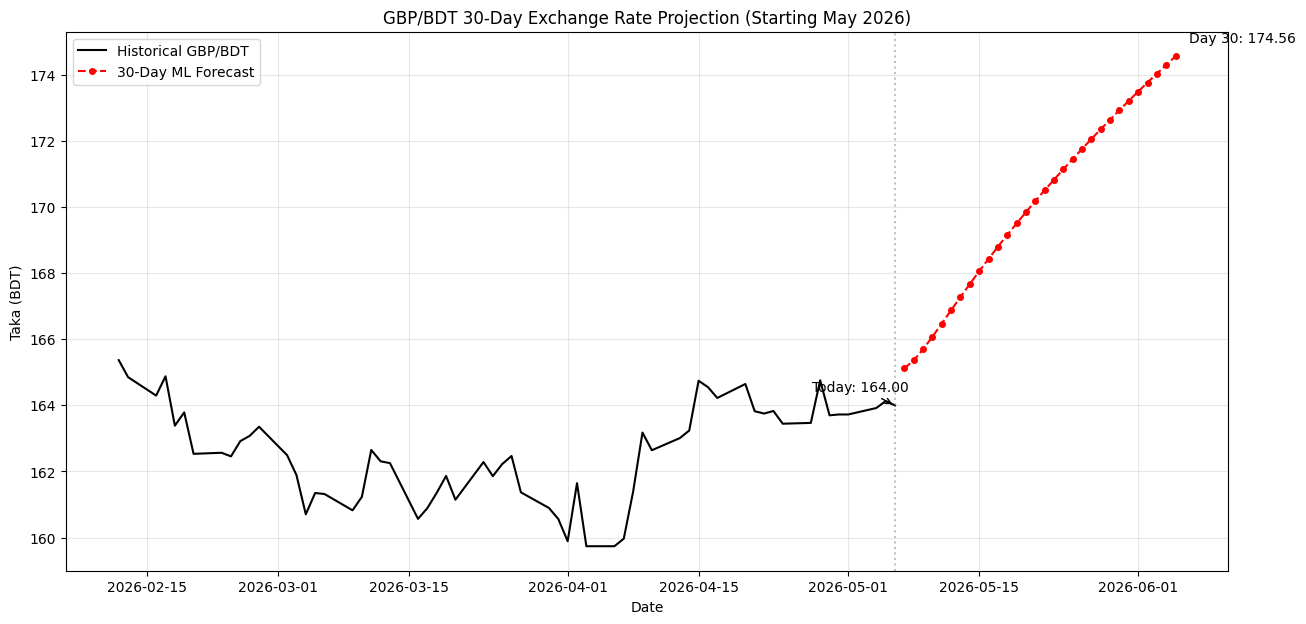


30-Day Forecast Summary:
             Predicted
2026-05-07  165.115974
2026-05-08  165.361805
2026-05-09  165.695860
2026-05-10  166.074447
2026-05-11  166.472407
2026-05-12  166.875580
2026-05-13  167.276116
2026-05-14  167.669903
2026-05-15  168.054949
2026-05-16  168.430556
2026-05-17  168.796728
2026-05-18  169.153908
2026-05-19  169.502638
2026-05-20  169.843606
2026-05-21  170.177443
2026-05-22  170.504716
2026-05-23  170.825951
2026-05-24  171.141547
2026-05-25  171.451882
2026-05-26  171.757196
2026-05-27  172.057718
2026-05-28  172.353591
2026-05-29  172.644947
2026-05-30  172.931856
2026-05-31  173.214373
2026-06-01  173.492542
2026-06-02  173.766374
2026-06-03  174.035906
2026-06-04  174.301118
2026-06-05  174.562053


In [103]:
# --- VISUALIZATION: 30-DAY OUTLOOK ---
plt.figure(figsize=(15, 7))

# Plot historical context (last 60 days)
plt.plot(data.index[-60:], data['GBP_BDT'][-60:], color='black', label='Historical GBP/BDT')

# Plot 30-day forecast
plt.plot(forecast_df.index, forecast_df['Predicted'], color='red', linestyle='--', marker='o', markersize=4, label='30-Day ML Forecast')

# Annotate current and final predicted price
# 1. Fix for the "Today" annotation
# Adding .item() extracts the single numerical value from the Pandas Series
today_val = data['GBP_BDT'].iloc[-1].item()
plt.annotate(f'Today: {today_val:.2f}', xy=(data.index[-1], today_val), xytext=(-60, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

# 2. Fix for the "Day 30" annotation
# Adding .item() here as well
day_30_val = forecast_df['Predicted'].iloc[-1].item()
plt.annotate(f'Day 30: {day_30_val:.2f}', xy=(forecast_df.index[-1], day_30_val), xytext=(10, 10), textcoords='offset points')

plt.title(f'GBP/BDT 30-Day Exchange Rate Projection (Starting May 2026)')
plt.xlabel('Date')
plt.ylabel('Taka (BDT)')
plt.legend()
plt.grid(True, alpha=0.3)
# Mark the "Now" line
plt.axvline(x=data.index[-1], color='gray', linestyle=':', alpha=0.5, label='Current Date')
plt.show()

print(f"\n30-Day Forecast Summary:")
print(forecast_df)

In [104]:
# --- 8. MODEL PERSISTENCE ---
# Save the entire model (architecture + weights)
model.save('gbp_bdt_lstm_model.keras')

print("\n✅ Model saved successfully as 'gbp_bdt_lstm_model.keras'")


✅ Model saved successfully as 'gbp_bdt_lstm_model.keras'
